# IS353 — Lab 1 & 2: Phân tích mạng với NetworkX

**MSSV:** 23520588

Phân tích hai đồ thị:

1. Toy network (`toy_edges.txt`) — hai cụm dày nối với nhau bằng vài cạnh cầu.
2. Facebook Social Circles (`facebook_combined.txt`) — [SNAP ego-Facebook](https://snap.stanford.edu/data/ego-Facebook.html).

Mỗi đồ thị gồm: thống kê cơ bản, clustering và đường đi, phân tích bậc, biểu đồ phân bố bậc, hình mạng (toàn cục và phóng to cụm dày), rồi xuất `.gexf` để mở trong Gephi.


## Cài thư viện


In [1]:
%pip install networkx matplotlib numpy scipy


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------------ --------------- 1.3/2.1 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 8.3 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 4.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.3 MB 7.6 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.3 MB 8.3 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 8.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 6.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 6.3 MB/s  0:00:01
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12

## Import


In [2]:
%matplotlib inline

from pathlib import Path
import gzip
import shutil
import urllib.request

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import scipy


## Hàm dùng chung


In [22]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_data_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "BT" / "Lab1_2",
        Path(r"d:/Study/IS353/BT/Lab1_2"),
    ]
    for folder in candidates:
        if (folder / "toy_edges.txt").exists():
            return folder
    raise FileNotFoundError(
        "Không thấy toy_edges.txt. Hãy chạy notebook trong thư mục BT/Lab1_2."
    )


DATA = find_data_dir()
FIG = DATA / "figures"
FIG.mkdir(exist_ok=True)


def basic_stats(G, name):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    avg_degree = (2 * m / n) if n else float("nan")
    density = nx.density(G)
    n_cc = nx.number_connected_components(G)
    print(f"=== {name} ===")
    print(f"Number of nodes                : {n}")
    print(f"Number of edges                : {m}")
    print(f"Average degree                 : {avg_degree:.4f}")
    print(f"Density                        : {density:.6f}")
    print(f"Number of connected components : {n_cc}")
    return {"nodes": n, "edges": m, "avg_degree": avg_degree, "density": density, "components": n_cc}


def clustering_and_paths(G, name):
    avg_clustering = nx.average_clustering(G)
    lcc_nodes = max(nx.connected_components(G), key=len)
    H = G.subgraph(lcc_nodes).copy()
    diameter = nx.diameter(H)
    avg_path = nx.average_shortest_path_length(H)
    print(f"=== {name} ===")
    print(f"Average clustering coefficient : {avg_clustering:.6f}")
    print(f"LCC nodes / edges              : {H.number_of_nodes()} / {H.number_of_edges()}")
    print(f"Diameter (LCC)                 : {diameter}")
    print(f"Average shortest path (LCC)    : {avg_path:.6f}")
    return H, avg_clustering, diameter, avg_path


def top_nodes_by_degree(G, k=10):
    return sorted(G.degree(), key=lambda item: (-item[1], str(item[0])))[:k]


def print_top_degree(G, name, k=10):
    print(f"=== Top {k} nodes by degree — {name} ===")
    print(f"{'Rank':<6}{'Node':<16}{'Degree':>8}")
    for rank, (node, degree) in enumerate(top_nodes_by_degree(G, k), start=1):
        print(f"{rank:<6}{str(node):<16}{degree:>8}")


def plot_degree_histogram(G, title, outfile):
    degrees = [degree for _, degree in G.degree()]
    low, high = min(degrees), max(degrees)
    span = high - low
    # Đồ thị nhỏ: mỗi bậc một cột. Facebook trải từ 1 đến hơn 1000,
    # viền trắng dày hơn bề rộng cột nên hình trông như trống.
    if span <= 40:
        bins = np.arange(low, high + 2) - 0.5
        edgecolor = "white"
        linewidth = 0.6
    else:
        bins = 40
        edgecolor = "#2F6F9F"
        linewidth = 0.3
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(degrees, bins=bins, color="#2F6F9F", edgecolor=edgecolor, linewidth=linewidth)
    ax.set_title(title)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Number of nodes")
    ax.set_xticks(range(low, high + 1, max(1, span // 12)))
    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outfile}")


def draw_network(G, pos, title, outfile, nodelist=None, labels=False, node_size_scale=80, node_size_base=40, edge_alpha=0.35, edge_width=0.8):
    if nodelist is None:
        nodelist = list(G.nodes())
    degrees = np.array([G.degree(node) for node in nodelist], dtype=float)
    sizes = node_size_base + node_size_scale * degrees
    fig, ax = plt.subplots(figsize=(9, 7))
    nx.draw_networkx_edges(
        G, pos, ax=ax, alpha=edge_alpha, width=edge_width, edge_color="#9AA3B2"
    )
    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodelist,
        ax=ax,
        node_size=sizes,
        node_color=degrees,
        cmap="viridis",
        linewidths=0.4,
        edgecolors="white",
    )
    if labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="#1F2933")
    cbar = fig.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Degree")
    ax.set_title(title)
    ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outfile}")
    return fig, ax

## Part A. Load & Explore (NetworkX)

## 1. Toy network

Đồ thị vô hướng, mỗi dòng một cạnh. Comment đầu file mô tả 10 đỉnh và hai cụm dày nối bởi vài liên kết cầu.


### 1.1 Load the graph


In [4]:
toy = nx.read_edgelist(DATA / "toy_edges.txt", create_using=nx.Graph)
print(f"Loaded toy graph: {toy.number_of_nodes()} nodes, {toy.number_of_edges()} edges")
print("Nodes:", ", ".join(sorted(toy.nodes())))

Loaded toy graph: 10 nodes, 16 edges
Nodes: Alice, Bob, Carol, Dave, Eve, Frank, Grace, Heidi, Ivan, Judy


### 1.2 Basic stats

- **Number of nodes / edges:** kích thước đồ thị.
- **Average degree:** \(2|E| / |V|\) với đồ thị vô hướng.
- **Density:** tỉ lệ cạnh thực tế trên số cạnh tối đa \(|V|(|V|-1)/2\).
- **Connected components:** số thành phần liên thông.


In [5]:
toy_stats = basic_stats(toy, "Toy network")


=== Toy network ===
Number of nodes                : 10
Number of edges                : 16
Average degree                 : 3.2000
Density                        : 0.355556
Number of connected components : 1


### 1.3 Clustering and paths

- **Average clustering coefficient** tính trên toàn đồ thị (`nx.average_clustering`).
- **Diameter** và **average shortest path length** tính trên thành phần liên thông lớn nhất (LCC). Với toy network, LCC chính là cả đồ thị.


In [6]:
toy_lcc, toy_clustering, toy_diameter, toy_aspl = clustering_and_paths(toy, "Toy network")

=== Toy network ===
Average clustering coefficient : 0.300000
LCC nodes / edges              : 10 / 16
Diameter (LCC)                 : 3
Average shortest path (LCC)    : 1.866667


### 1.4 Degree-based analysis

Top 10 đỉnh theo bậc, rồi histogram phân bố bậc. Đỉnh bậc cao là các cầu nối hoặc tâm của cụm.


=== Top 10 nodes by degree — Toy network ===
Rank  Node              Degree
1     Carol                  4
2     Frank                  4
3     Grace                  4
4     Alice                  3
5     Bob                    3
6     Dave                   3
7     Eve                    3
8     Heidi                  3
9     Ivan                   3
10    Judy                   2


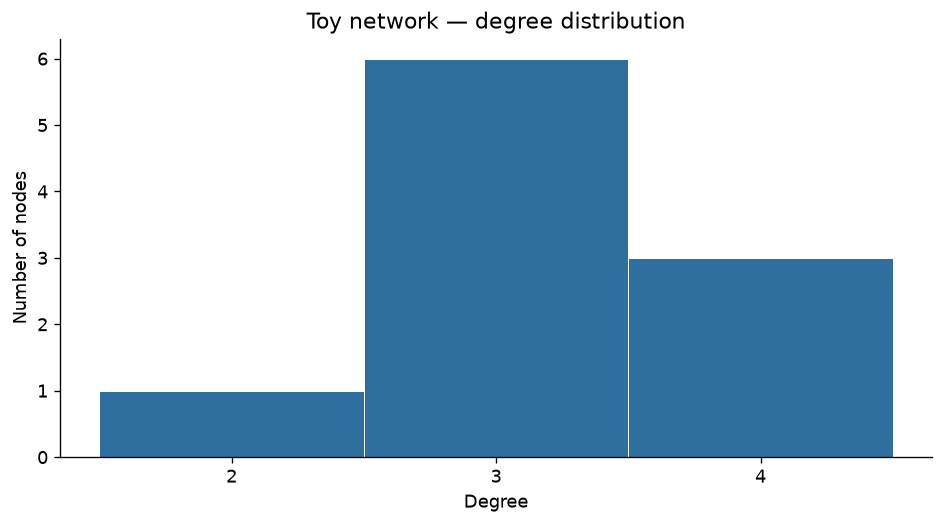

Saved: d:\Study\IS353\BT\Lab1+2\figures\toy_degree_hist.png


In [7]:
print_top_degree(toy, "Toy network")
plot_degree_histogram(
    toy,
    "Toy network — degree distribution",
    FIG / "toy_degree_hist.png",
)


### 1.5 Visualization (Matplotlib)

Hình 1: toàn bộ mạng, kích thước và màu nút theo bậc.


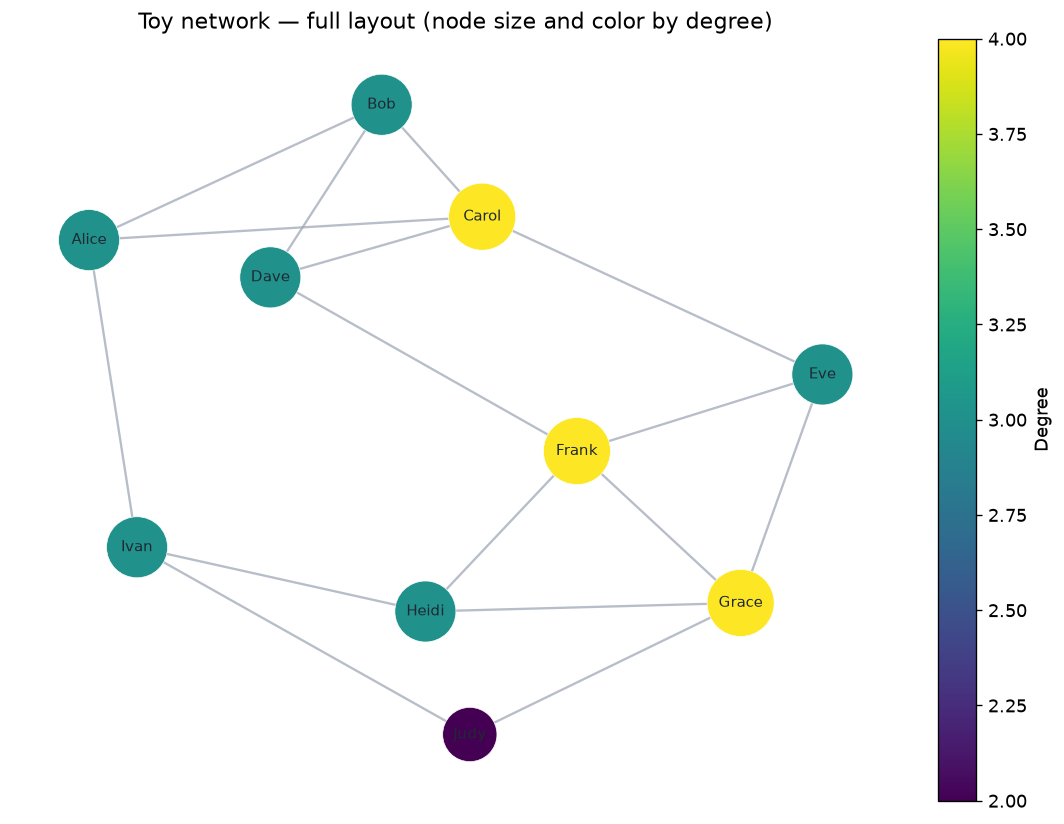

Saved: d:\Study\IS353\BT\Lab1+2\figures\toy_network_full.png


(<Figure size 1080x840 with 2 Axes>,
 <Axes: title={'center': 'Toy network — full layout (node size and color by degree)'}>)

In [10]:
toy_pos = nx.spring_layout(toy, seed=42, k=0.9)

draw_network(
    toy,
    toy_pos,
    "Toy network — full layout (node size and color by degree)",
    FIG / "toy_network_full.png",
    labels=True,
    node_size_scale=280,
    node_size_base=500,
    edge_alpha=0.7,
    edge_width=1.4,
)


Hình 2: phóng vào cụm dày thứ hai (`Eve`, `Frank`, `Grace`, `Heidi`, `Ivan`, `Judy`). Cụm còn lại (`Alice`–`Dave`) nối sang đây qua `Carol–Eve`, `Dave–Frank` và `Alice–Ivan`.

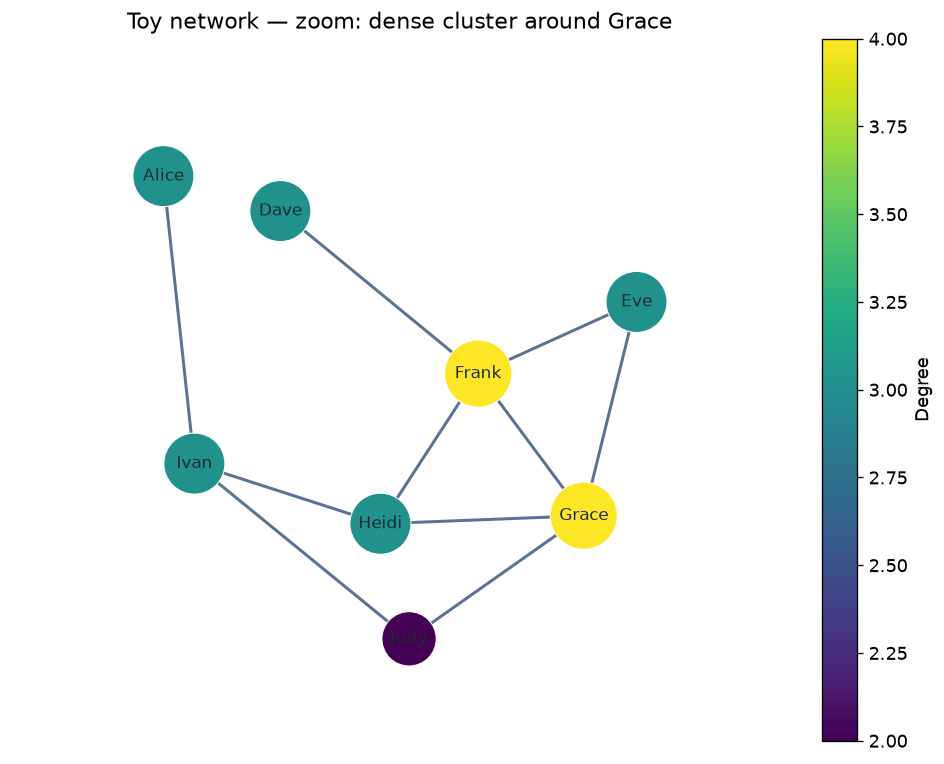

Saved: d:\Study\IS353\BT\Lab1+2\figures\toy_network_zoom.png


In [13]:
toy_pos = nx.spring_layout(toy, seed=42, k=0.9)

cluster_nodes = ["Eve", "Frank", "Grace", "Heidi", "Ivan", "Judy"]
bridge_nodes = ["Alice", "Dave"]
show_nodes = cluster_nodes + bridge_nodes
show = toy.subgraph(show_nodes).copy()
fig, ax = plt.subplots(figsize=(8, 6.5))
degrees = np.array([toy.degree(n) for n in show_nodes], dtype=float)
nx.draw_networkx_edges(
    show, toy_pos, ax=ax, alpha=0.85, width=1.8, edge_color="#3D5A80"
)
nodes = nx.draw_networkx_nodes(
    show,
    toy_pos,
    nodelist=show_nodes,
    ax=ax,
    node_size=500 + 280 * degrees,
    node_color=degrees,
    cmap="viridis",
    linewidths=0.6,
    edgecolors="white",
)
nx.draw_networkx_labels(show, toy_pos, ax=ax, font_size=10, font_color="#1F2933")
xs = np.array([toy_pos[n][0] for n in show_nodes])
ys = np.array([toy_pos[n][1] for n in show_nodes])
pad_x = 0.32 * (xs.max() - xs.min())
pad_y = 0.22 * (ys.max() - ys.min())
ax.set_xlim(xs.min() - pad_x, xs.max() + pad_x)
ax.set_ylim(ys.min() - pad_y, ys.max() + pad_y + 0.12)
cbar = fig.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Degree")
ax.set_title("Toy network — zoom: dense cluster around Grace")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIG / "toy_network_zoom.png", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG / 'toy_network_zoom.png'}")


In [14]:
toy_gexf = DATA / "toy_edges.gexf"
nx.write_gexf(toy, toy_gexf)
print(f"Exported: {toy_gexf}")


Exported: d:\Study\IS353\BT\Lab1+2\toy_edges.gexf


## 2. Facebook Social Circles (ego-Facebook)

File `facebook_combined.txt` là danh sách cạnh vô hướng của các vòng kết bạn Facebook, gộp từ 10 ego-network. Nếu file chưa có, cell bên dưới tải `facebook_combined.txt.gz` từ SNAP và giải nén.


### 2.1 Load the graph


In [25]:
fb_path = DATA / "facebook_combined.txt"
if not fb_path.exists():
    gz_path = DATA / "facebook_combined.txt.gz"
    url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, gz_path)
    with gzip.open(gz_path, "rb") as src, open(fb_path, "wb") as dst:
        shutil.copyfileobj(src, dst)
    print(f"Unzipped: {fb_path}")

facebook = nx.read_edgelist(fb_path, create_using=nx.Graph)
print(f"Loaded Facebook graph: {facebook.number_of_nodes()} nodes, {facebook.number_of_edges()} edges")


Loaded Facebook graph: 4039 nodes, 88234 edges


### 2.2 Basic stats


In [26]:
fb_stats = basic_stats(facebook, "Facebook Social Circles")


=== Facebook Social Circles ===
Number of nodes                : 4039
Number of edges                : 88234
Average degree                 : 43.6910
Density                        : 0.010820
Number of connected components : 1


### 2.3 Clustering and paths

Đường kính và độ dài đường đi trung bình duyệt BFS từ mọi đỉnh trên LCC. Với khoảng 4.000 đỉnh, bước này mất khoảng một phút.


In [27]:
fb_lcc, fb_clustering, fb_diameter, fb_aspl = clustering_and_paths(
    facebook, "Facebook Social Circles"
)


=== Facebook Social Circles ===
Average clustering coefficient : 0.605547
LCC nodes / edges              : 4039 / 88234
Diameter (LCC)                 : 8
Average shortest path (LCC)    : 3.692507


### 2.4 Degree-based analysis


=== Top 10 nodes by degree — Facebook Social Circles ===
Rank  Node              Degree
1     107                 1045
2     1684                 792
3     1912                 755
4     3437                 547
5     0                    347
6     2543                 294
7     2347                 291
8     1888                 254
9     1800                 245
10    1663                 235


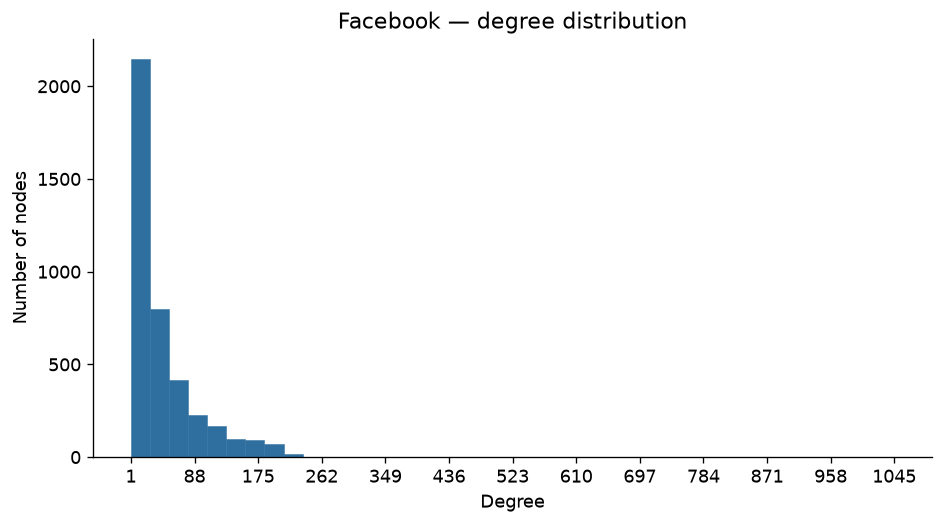

Saved: d:\Study\IS353\BT\Lab1+2\figures\facebook_degree_hist.png


In [28]:
print_top_degree(facebook, "Facebook Social Circles")
plot_degree_histogram(
    facebook,
    "Facebook — degree distribution",
    FIG / "facebook_degree_hist.png",
)


### 2.5 Visualization (Matplotlib)

Hình toàn mạng dùng layout Fruchterman–Reingold (`spring_layout`). Mạng 4.000 đỉnh rất dày, nên cạnh được vẽ mờ để còn thấy các vùng đậm.


In [30]:
%pip install scipy
import scipy

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
    --------------------------------------- 0.5/36.6 MB 3.9 MB/s eta 0:00:10
   - -------------------------------------- 1.6/36.6 MB 5.2 MB/s eta 0:00:07
   -- ------------------------------------- 2.6/36.6 MB 5.2 MB/s eta 0:00:07
   ---- ----------------------------------- 4.2/36.6 MB 5.6 MB/s eta 0:00:06
   ------ --------------------------------- 5.8/36.6 MB 6.0 MB/s eta 0:00:06
   -------- ------------------------------- 7.9/36.6 MB 6.7 MB/s eta 0:00:05
   ---------- ----------------------------- 9.7/36.6 MB 7.1 MB/s eta 0:00:04
   ------------ --------------------------- 11.0/36.6 MB 7.0 MB/s eta 0:00:04
   ------------ --------------------------- 11.5/36.6 MB 6.5 MB/s eta 0:00:04
   -------------- ------------------------- 13.1/36.6 MB 6.5 MB/s eta 0:00:04
   ---------------- ----------------------- 15.5/36.6 MB 6.9 MB/s eta 0:00:04
   ------------------- -------------------- 17.6/36.6 MB 7.3 MB/s eta 0:00:03
 

Computing spring layout (Facebook)...


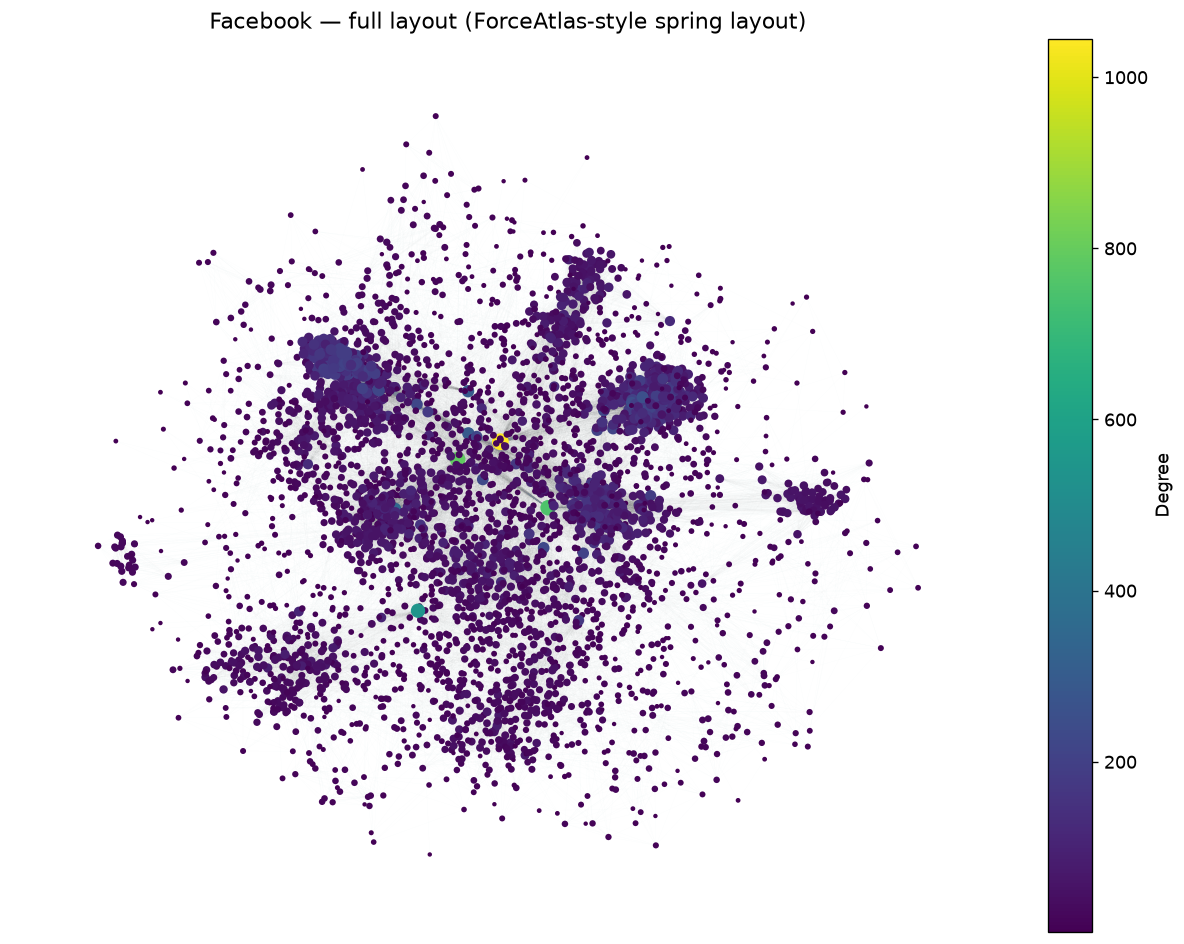

Saved: d:\Study\IS353\BT\Lab1+2\figures\facebook_network_full.png


In [31]:
print("Computing spring layout (Facebook)...")
fb_pos = nx.spring_layout(facebook, seed=42, iterations=30, k=1 / np.sqrt(facebook.number_of_nodes()))

fb_nodes = list(facebook.nodes())
fb_degrees = np.array([facebook.degree(node) for node in fb_nodes], dtype=float)
fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(
    facebook, fb_pos, ax=ax, alpha=0.015, width=0.25, edge_color="#7B8794"
)
nodes = nx.draw_networkx_nodes(
    facebook,
    fb_pos,
    nodelist=fb_nodes,
    ax=ax,
    node_size=4 + 3 * np.sqrt(fb_degrees),
    node_color=fb_degrees,
    cmap="viridis",
    linewidths=0,
)
cbar = fig.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Degree")
ax.set_title("Facebook — full layout (ForceAtlas-style spring layout)")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIG / "facebook_network_full.png", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG / 'facebook_network_full.png'}")


Hình phóng to là ego-network bán kính 1 của một đỉnh có bậc vừa phải và hệ số cụm cao: láng giềng kết nối chặt với nhau, đúng kiểu cụm dày cục bộ.

Zoom center: node 595 | degree 19 | local clustering 0.988 | ego nodes 20


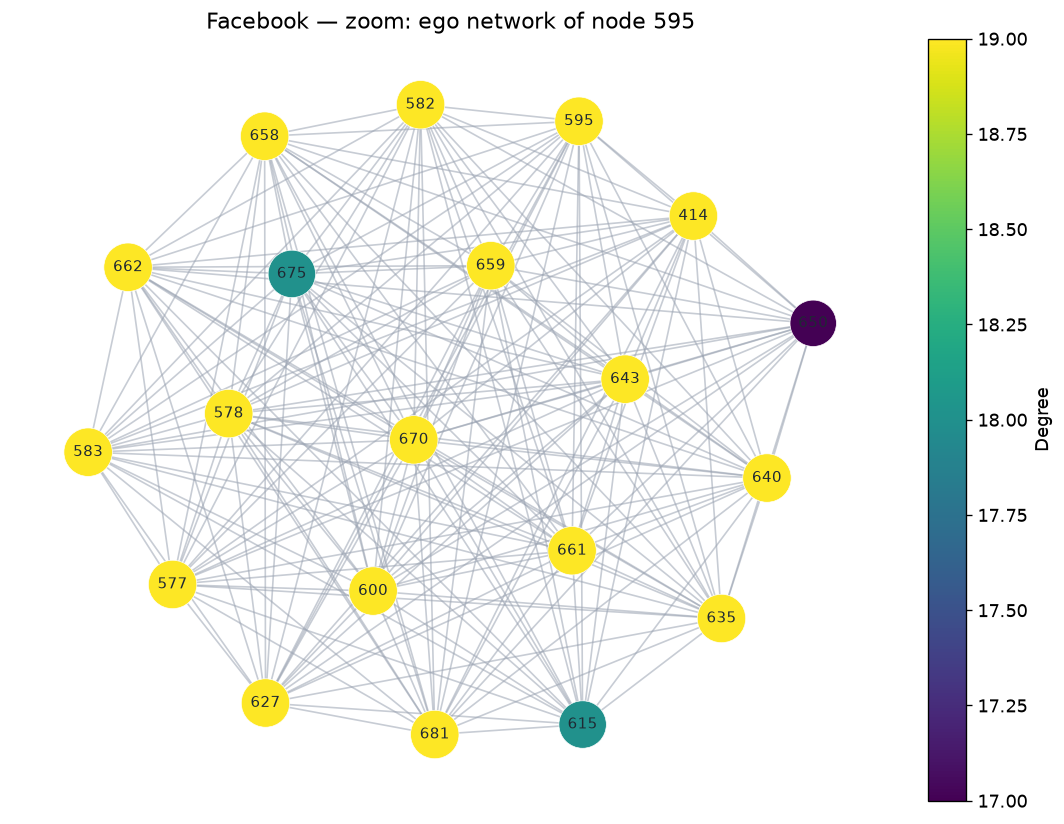

Saved: d:\Study\IS353\BT\Lab1+2\figures\facebook_network_zoom.png


(<Figure size 1080x840 with 2 Axes>,
 <Axes: title={'center': 'Facebook — zoom: ego network of node 595'}>)

In [32]:
clustering_local = nx.clustering(facebook)
candidates = [
    node
    for node, degree in facebook.degree()
    if 12 <= degree <= 30 and clustering_local[node] >= 0.5
]
center = max(candidates, key=lambda node: (clustering_local[node], facebook.degree(node)))
ego = nx.ego_graph(facebook, center, radius=1)
print(
    f"Zoom center: node {center} | degree {facebook.degree(center)} | "
    f"local clustering {clustering_local[center]:.3f} | ego nodes {ego.number_of_nodes()}"
)

ego_pos = nx.spring_layout(ego, seed=7, k=0.55)
draw_network(
    ego,
    ego_pos,
    f"Facebook — zoom: ego network of node {center}",
    FIG / "facebook_network_zoom.png",
    labels=True,
    node_size_scale=35,
    node_size_base=180,
    edge_alpha=0.55,
    edge_width=1.0,
)


In [33]:
fb_gexf = DATA / "facebook_combined.gexf"
nx.write_gexf(facebook, fb_gexf)
print(f"Exported: {fb_gexf}")

Exported: d:\Study\IS353\BT\Lab1+2\facebook_combined.gexf


## 3. So sánh nhanh hai mạng


In [34]:
rows = [
    ("Nodes", toy_stats["nodes"], fb_stats["nodes"]),
    ("Edges", toy_stats["edges"], fb_stats["edges"]),
    ("Average degree", round(toy_stats["avg_degree"], 4), round(fb_stats["avg_degree"], 4)),
    ("Density", round(toy_stats["density"], 6), round(fb_stats["density"], 6)),
    ("Connected components", toy_stats["components"], fb_stats["components"]),
    ("Average clustering", round(toy_clustering, 6), round(fb_clustering, 6)),
    ("Diameter (LCC)", toy_diameter, fb_diameter),
    ("Avg. shortest path (LCC)", round(toy_aspl, 6), round(fb_aspl, 6)),
]
print(f"{'Metric':<28}{'Toy':>16}{'Facebook':>16}")
for name, toy_value, fb_value in rows:
    print(f"{name:<28}{str(toy_value):>16}{str(fb_value):>16}")


Metric                                   Toy        Facebook
Nodes                                     10            4039
Edges                                     16           88234
Average degree                           3.2          43.691
Density                             0.355556         0.01082
Connected components                       1               1
Average clustering                       0.3        0.605547
Diameter (LCC)                             3               8
Avg. shortest path (LCC)            1.866667        3.692507


## Part B — Gephi


Hai đồ thị được xuất sang `toy_edges.gexf` và `facebook_combined.gexf`.

Toy network dùng layout Fruchterman–Reingold vì đồ thị nhỏ. Facebook dùng ForceAtlas2. Nút tô màu và chỉnh kích thước theo bậc, nên đỉnh bậc cao nổi hơn nút lá. Cả hai mạng đều có một thành phần liên thông.

Mỗi mạng có hai hình: một hình toàn bộ layout và một hình phóng vào vùng cạnh dày, nơi các cụm cục bộ hiện rõ.

Truy cập https://gephi.org/

Toy network:

![Toy network](gexf_figures/toy_edges.png)

Facebook, toàn mạng:

![Facebook full layout](gexf_figures/facebook_combined_full.png)

Facebook, phóng to cụm:

![Facebook zoom](gexf_figures/facebook_combined_zoom.jpg)


Hình Matplotlib tương ứng nằm trong `figures/` và được in ở cell bên dưới.

| File | Nội dung |
| --- | --- |
| `figures/toy_degree_hist.png` | Histogram bậc — toy |
| `figures/toy_network_full.png` | Layout đầy đủ — toy |
| `figures/toy_network_zoom.png` | Phóng to cụm dày — toy |
| `figures/facebook_degree_hist.png` | Histogram bậc — Facebook |
| `figures/facebook_network_full.png` | Layout đầy đủ — Facebook |
| `figures/facebook_network_zoom.png` | Ego-network cục bộ — Facebook |


### Toy — degree distribution

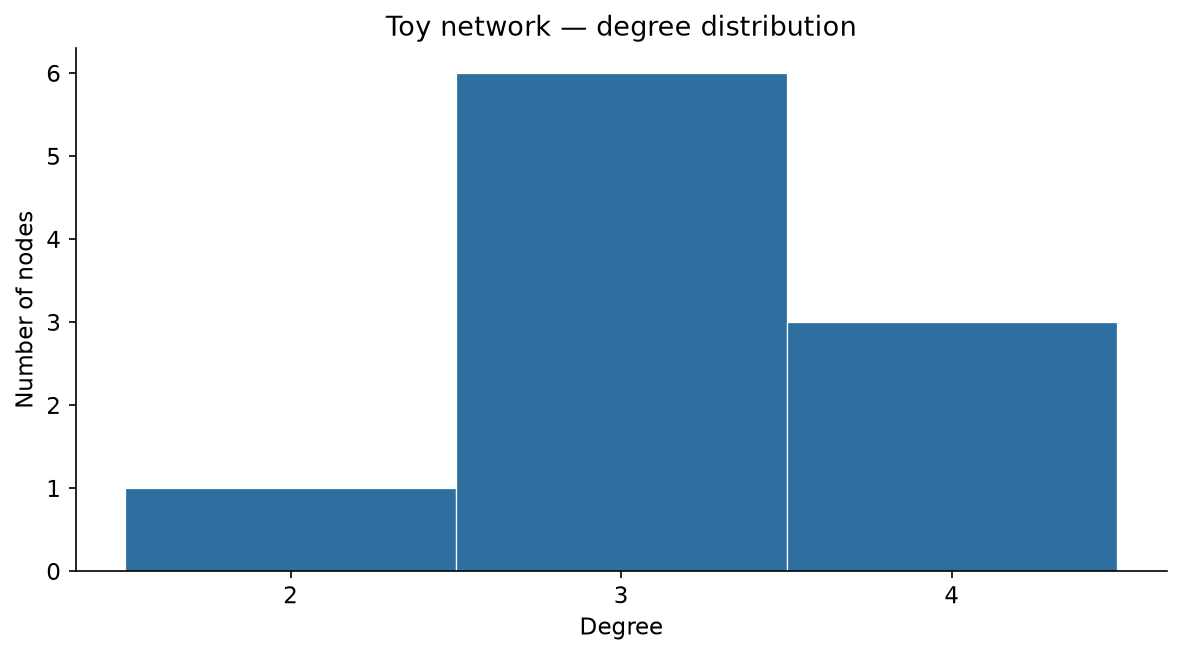

### Toy — full layout

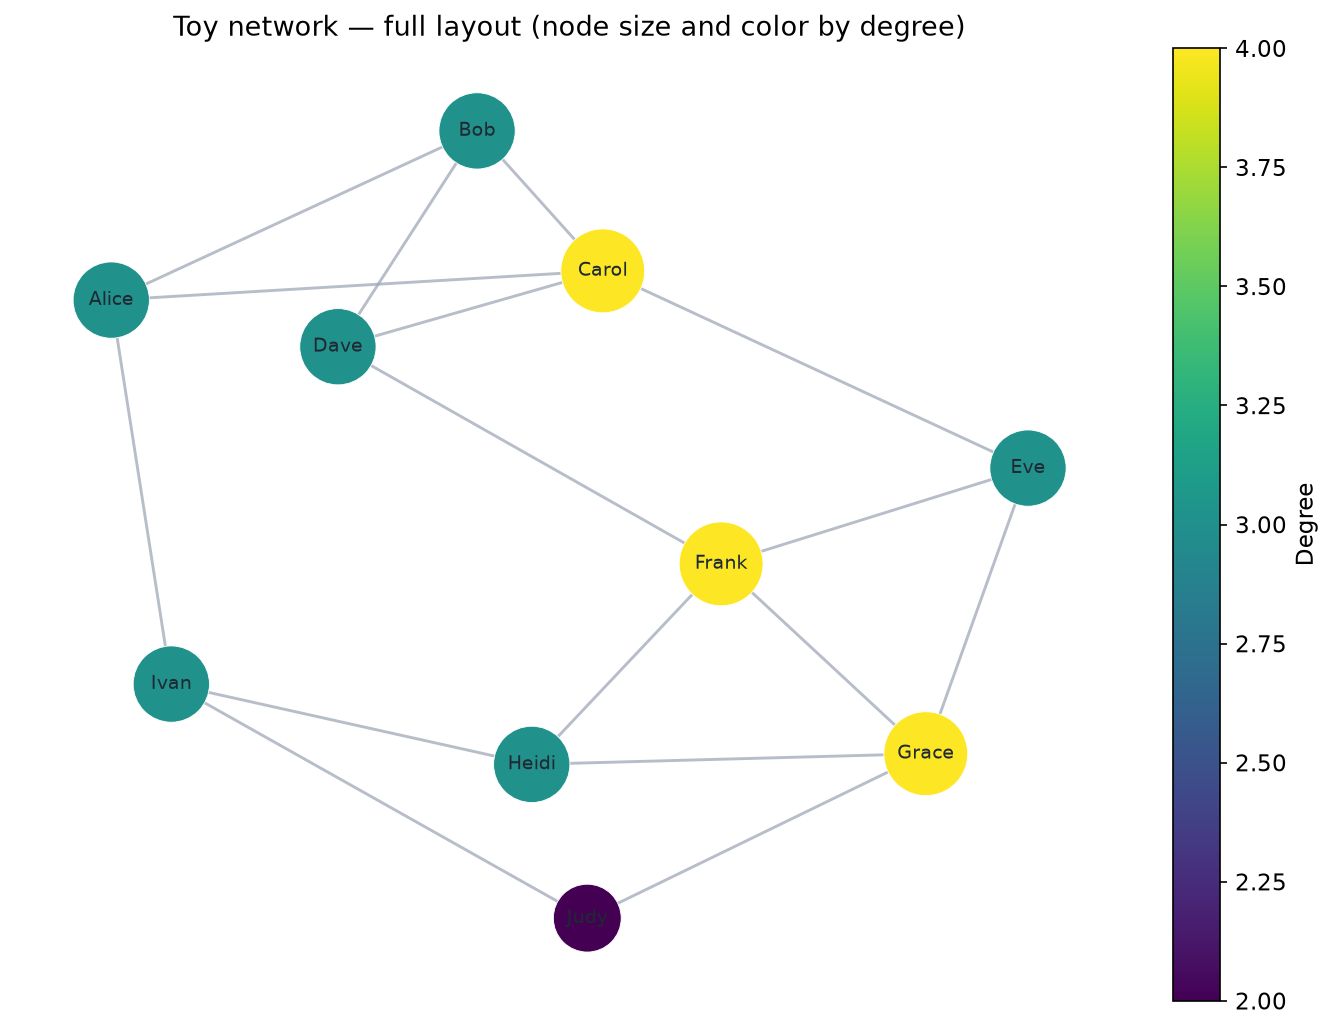

### Toy — zoom: dense cluster

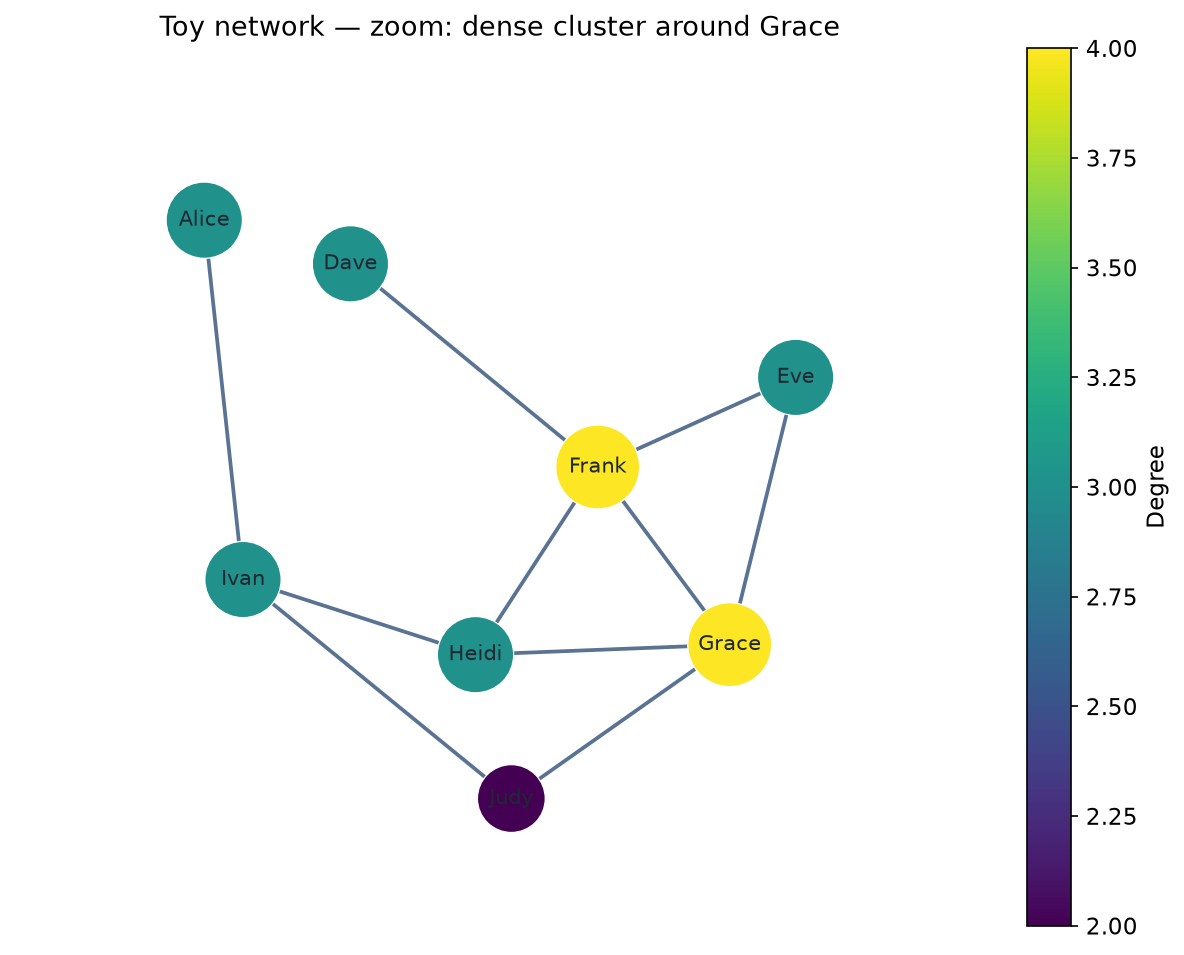

### Facebook — degree distribution

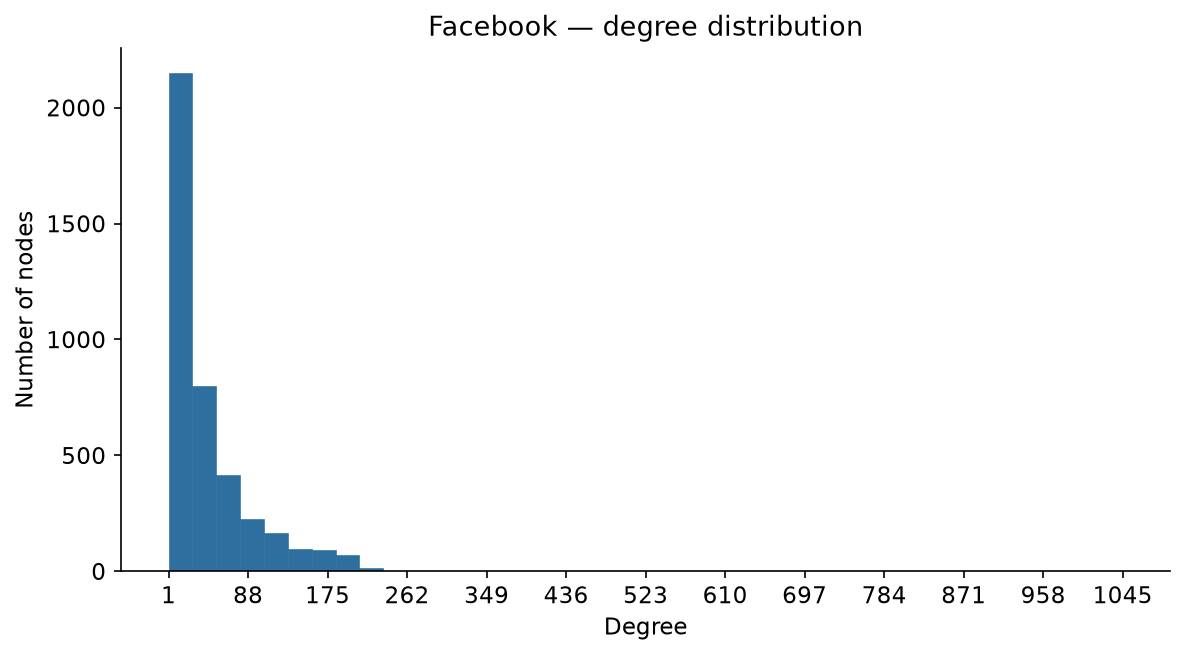

### Facebook — full layout

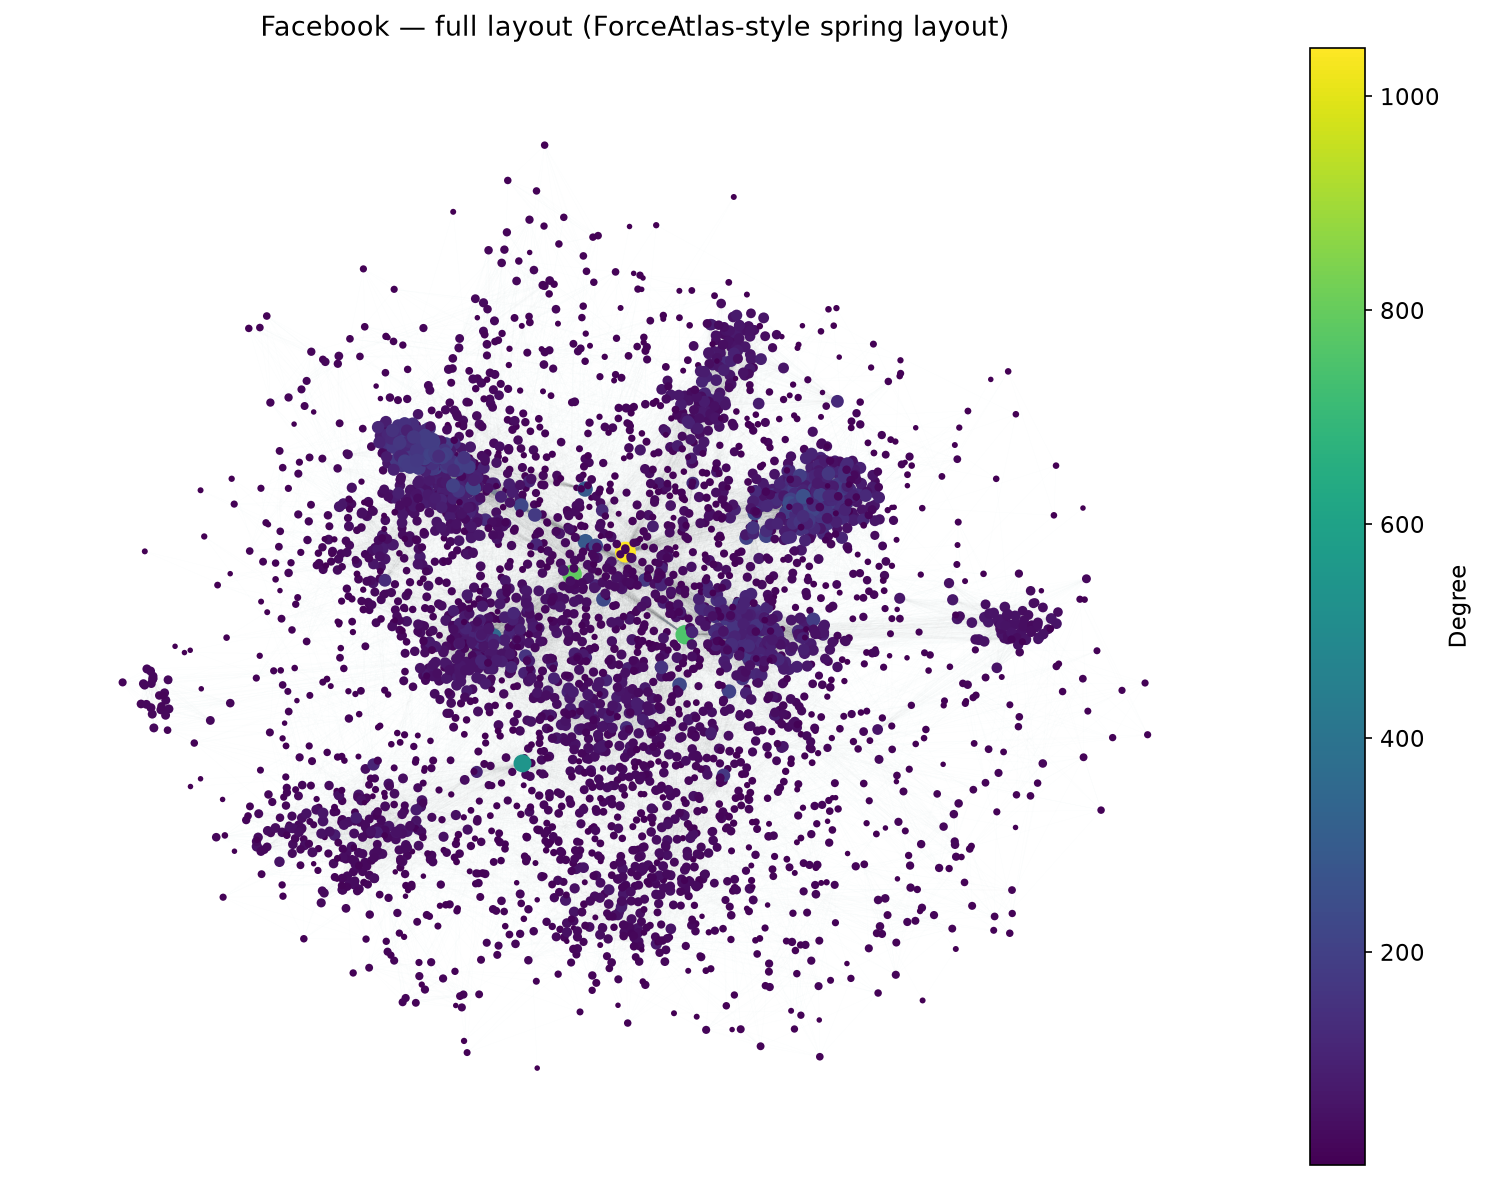

### Facebook — zoom: local cluster

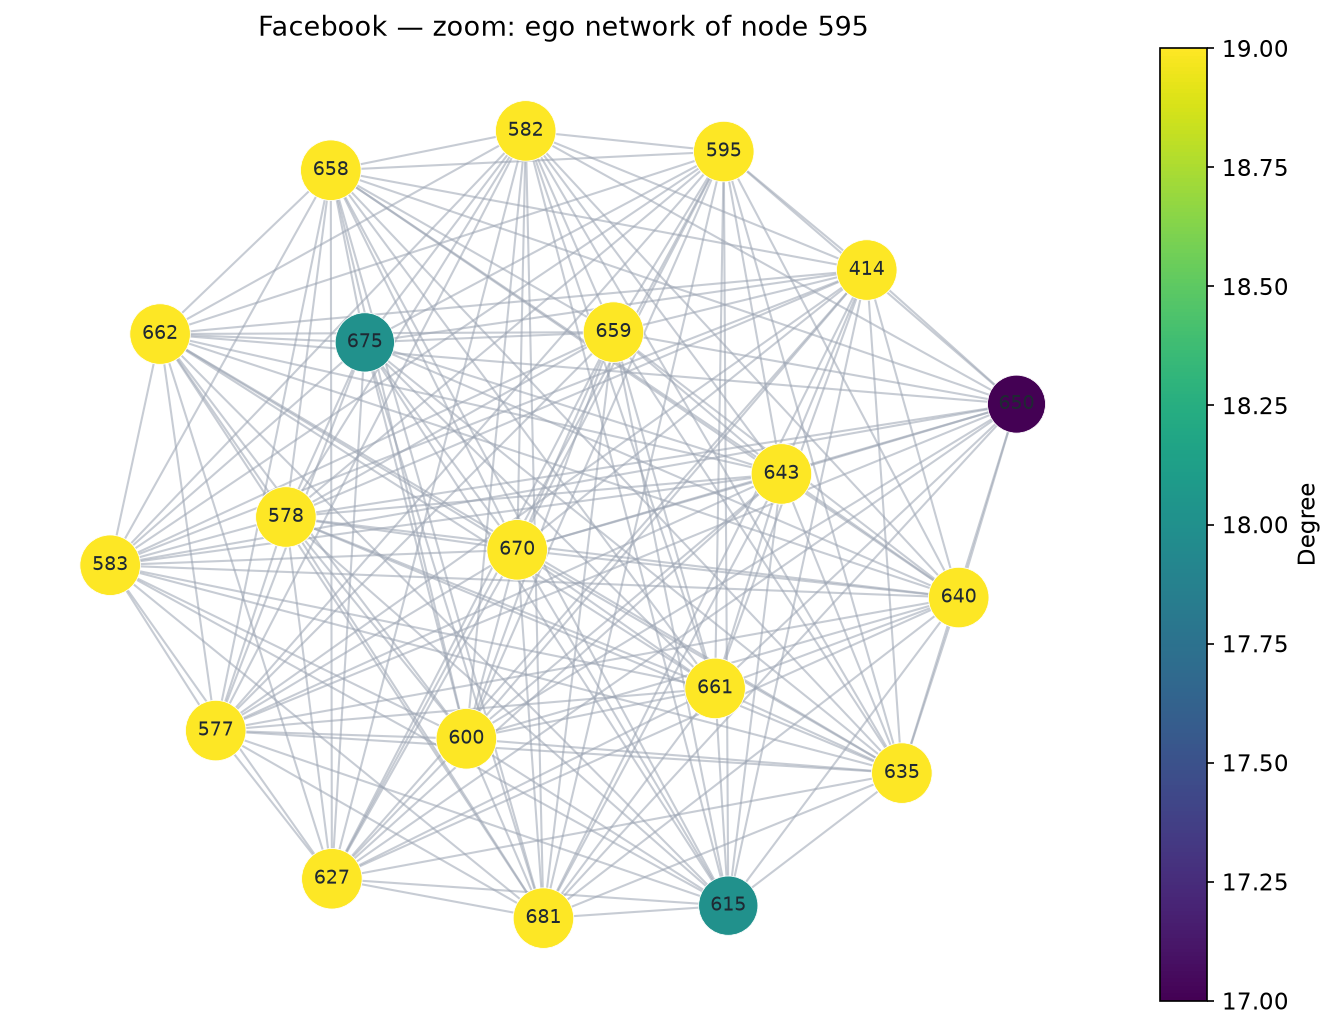

In [ ]:
from IPython.display import Image, Markdown, display

figures = [
    ("Toy — degree distribution", FIG / "toy_degree_hist.png"),
    ("Toy — full layout", FIG / "toy_network_full.png"),
    ("Toy — zoom: dense cluster", FIG / "toy_network_zoom.png"),
    ("Facebook — degree distribution", FIG / "facebook_degree_hist.png"),
    ("Facebook — full layout", FIG / "facebook_network_full.png"),
    ("Facebook — zoom: local cluster", FIG / "facebook_network_zoom.png"),
]
for title, path in figures:
    display(Markdown(f"### {title}"))
    display(Image(filename=str(path)))
